# Indian E-Commerce Sales Analysis
## Notebook 03: Analysis & Insights

**Goal:** Answer the business questions using the cleaned data and turn findings into recommendations.

**Metric definitions (from Notebook 01):**
- **GMV** = Total_Amount of all orders (total customer demand)
- **Net Revenue** = Total_Amount of Delivered orders only (money actually earned)

## Executive Summary

**Data:** 250,000 orders from a simulated Indian e-commerce dataset (sales, customers and products tables), June 2024 – June 2026, covering ~40,000 customers, 2,000 products, 10 states and 39 cities.

### Headline numbers
| Metric | Value |
|---|---|
| GMV (all orders) | ₹593.07 crore |
| Net Revenue (delivered) | ₹474.16 crore |
| Lost to cancellations/returns | ₹60.25 crore (10.2% of GMV) |
| Typical order (median) | ₹8,332 (mean ₹23,691, skewed by high-value orders) |
| Orders per customer | ~6.3 |

### Key findings
1. **Revenue is concentrated in Electronics:** ~72% of revenue from ~27% of orders; 5 Electronics brands earn ~73% of revenue; 379 products (18.9%) generate 80% of revenue.
2. **Coupons cost ₹5.01 crore, and 97% comes from one coupon:** SAVE10 has no maximum discount (up to ₹38,279 on a single order). Flat coupons (DIWALI100, FLAT50) have no minimum order value, creating loss-making orders with discounts up to 383% of the basket. DIWALI100 runs all year (5.2% of orders in festive months vs 5.0% otherwise).
3. **A hidden free-shipping rule:** every order below ~₹500 pays shipping, every order above ships free. Books (30.4%) and Grocery (26.4%) orders pay shipping most often.
4. **High-value customers are slipping away:** 6,975 "At Risk" customers spent as much as Loyal customers (₹1.42 lakh each on average) but haven't ordered in ~8 months. They represent ~₹99 crore of historic revenue.
5. **Platinum customers drive the business:** 69% of customers generate 94% of revenue, mainly through ~10× larger orders, not more frequent ones.

### Recommendations
1. **Cap SAVE10:** a ₹2,000 cap would save up to ₹2.82 crore (58% of its cost) while affecting only one-third of SAVE10 users; a ₹500 cap would save up to ₹4.12 crore.
2. **Win back At Risk customers** with personalised offers; they are the highest-value group at risk of churning.
3. **Protect stock of the 379 hero products**, and reduce dependence on Electronics over time.
4. **Fix flat coupons:** add a minimum order value (e.g. ₹499) and restrict DIWALI100 to the festive season.
5. **Use the ₹500 threshold:** bundles or "add ₹X for free shipping" prompts in Books, Grocery and Beauty.
6. **Grow by adding cities:** every city contributes a similar ~₹12 crore, and customers behave the same across regions.

### Findings that looked real but were not
- **February "dip":** caused by fewer days in the month. Revenue per day is stable (₹60.6–65.2 lakh).
- **State ranking:** driven by how many cities each state has in the data, not market strength (revenue per city ₹11.9–12.7 crore everywhere).
- **Age vs spending:** each age group buys from exactly three categories, a rule built into the simulated data.

### Hypotheses tested and not supported
- COD orders are not riskier than prepaid orders (chi-square p = 0.96).
- No festive (Diwali) revenue uplift (festive months −0.4% vs other months).
- Delivery speed has no relationship with ratings (correlation −0.002).

### Methods
Data validation (formula checks, referential integrity, business-logic checks), cleaning without removing any orders, feature engineering, normalisation (per day, per city), chi-square significance testing, Pareto analysis and RFM segmentation.

**Important:** this dataset is simulated. See the **Limitations** section at the end for 12 patterns that confirm this and limit how far the findings apply to real decisions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.options.display.float_format = "{:,.2f}".format

In [2]:
df = pd.read_csv(
    "../data/processed/clean_sales.csv",
    parse_dates=["Order_Date", "Delivery_Date", "Registration_Date"]
)
print(df.shape)

(250000, 37)


In [3]:
df[["Order_Date", "Year_Month", "Total_Amount", "Has_Coupon", "Free_Shipping", "Delivery_Days"]].dtypes

Order_Date       datetime64[us]
Year_Month                  str
Total_Amount            float64
Has_Coupon                 bool
Free_Shipping              bool
Delivery_Days           float64
dtype: object

In [4]:
delivered = df[df["Status_Group"] == "Completed"]
print("Delivered orders:", len(delivered))

Delivered orders: 200139


## 1. Headline KPIs

**Question:** What is the overall size and health of the business?

In [5]:
gmv = df["Total_Amount"].sum()
net_revenue = delivered["Total_Amount"].sum()
lost_value = df.loc[df["Status_Group"] == "Lost", "Total_Amount"].sum()

total_orders = len(df)
delivered_orders = len(delivered)
unique_customers = df["Customer_ID"].nunique()

aov_mean = delivered["Total_Amount"].mean()
aov_median = delivered["Total_Amount"].median()

cancel_rate = (df["Order_Status"] == "Cancelled").mean() * 100
return_rate = (df["Order_Status"] == "Returned").mean() * 100

In [6]:
print(f"GMV (all orders):        ₹{gmv:,.0f}  (₹{gmv/1e7:,.2f} crore)")
print(f"Net Revenue (delivered): ₹{net_revenue:,.0f}  (₹{net_revenue/1e7:,.2f} crore)")
print(f"Lost to cancel/return:   ₹{lost_value:,.0f}  ({lost_value/gmv*100:.1f}% of GMV)")
print()
print(f"Total orders:      {total_orders:,}")
print(f"Delivered orders:  {delivered_orders:,}")
print(f"Unique customers:  {unique_customers:,}")
print()
print(f"AOV (mean):   ₹{aov_mean:,.0f}")
print(f"AOV (median): ₹{aov_median:,.0f}")
print(f"Cancellation rate: {cancel_rate:.1f}%")
print(f"Return rate:       {return_rate:.1f}%")

GMV (all orders):        ₹5,930,693,318  (₹593.07 crore)
Net Revenue (delivered): ₹4,741,566,406  (₹474.16 crore)
Lost to cancel/return:   ₹602,545,270  (10.2% of GMV)

Total orders:      250,000
Delivered orders:  200,139
Unique customers:  39,914

AOV (mean):   ₹23,691
AOV (median): ₹8,332
Cancellation rate: 5.0%
Return rate:       5.0%


**Insight (headline KPIs):**
- Customers placed orders worth ₹593.07 crore (GMV); ₹474.16 crore was actually earned from delivered orders (Net Revenue).
- 10.2% of GMV (₹60.25 crore) was lost to cancellations and returns.
- 39,914 unique customers placed 250,000 orders (about 6.3 orders per customer).
- The typical delivered order is ₹8,332 (median), much lower than the mean of ₹23,691, because a few high-value orders (e.g. laptops) raise the average.
- Cancellation rate 5.0%; return rate 5.0%.
- The remaining ~₹58.66 crore (9.9% of GMV) is in Incomplete orders (Shipped/Processing), so only ~80% of GMV became earned revenue.
- 39,914 of the 40,000 registered customers placed at least one order; 86 customers never ordered.

## 2. Sales Trend

**Question:** How does Net Revenue change month by month? Are there festive-season peaks (Diwali 2024 and 2025)?

In [7]:
monthly = delivered.groupby("Year_Month").agg(
    Net_Revenue=("Total_Amount", "sum"),
    Orders=("Order_ID", "count")
)
monthly["Revenue_Cr"] = monthly["Net_Revenue"] / 1e7
monthly

,Net_Revenue,Orders,Revenue_Cr
Year_Month,,,
2024-06,"190,829,185.97",7962,19.08
2024-07,"191,386,725.49",8107,19.14
2024-08,"190,099,256.47",8088,19.01
2024-09,"181,964,871.65",7725,18.20
2024-10,"189,216,899.47",7985,18.92
2024-11,"187,632,524.36",7882,18.76
2024-12,"192,912,517.77",8103,19.29
2025-01,"194,711,349.63",8216,19.47
2025-02,"172,127,381.41",7378,17.21


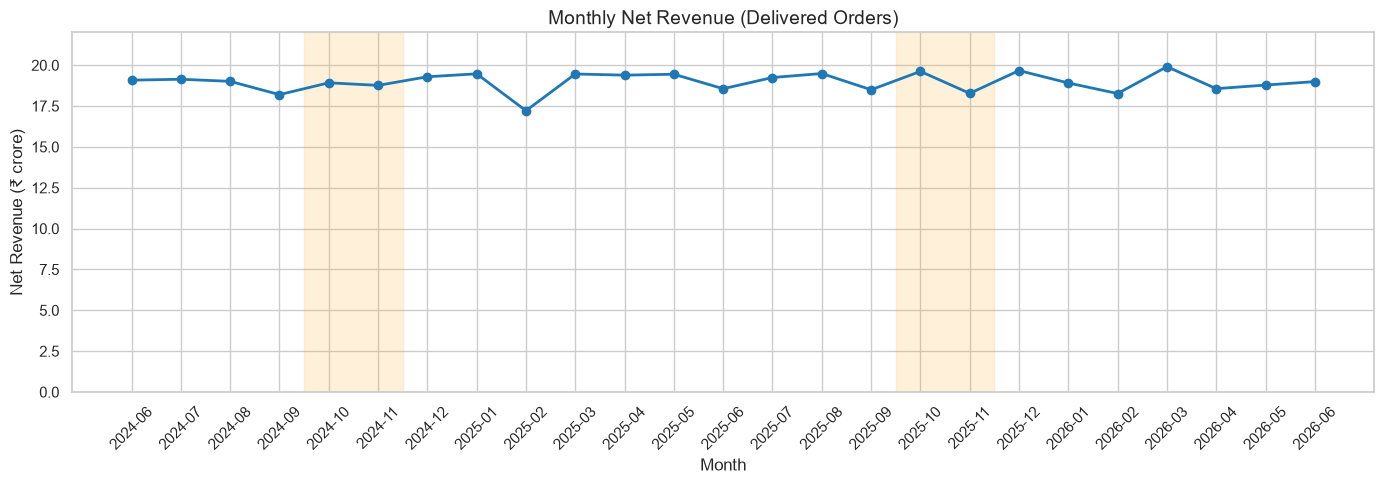

In [8]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(monthly.index, monthly["Revenue_Cr"], marker="o", linewidth=2, color="#1f77b4")

months = list(monthly.index)
for start in ["2024-10", "2025-10"]:
    i = months.index(start)
    ax.axvspan(i - 0.5, i + 1.5, color="orange", alpha=0.15)

ax.set_title("Monthly Net Revenue (Delivered Orders)", fontsize=14)
ax.set_xlabel("Month")
ax.set_ylabel("Net Revenue (₹ crore)")
plt.xticks(rotation=45)
ax.set_ylim(0, 22)
plt.tight_layout()
plt.savefig("../images/01_monthly_revenue_trend.png", dpi=150, bbox_inches="tight")
plt.show()

In [9]:
festive_months = ["2024-10", "2024-11", "2025-10", "2025-11"]
is_festive = monthly.index.isin(festive_months)

festive_avg = monthly.loc[is_festive, "Net_Revenue"].mean()
normal_avg = monthly.loc[~is_festive, "Net_Revenue"].mean()
uplift = (festive_avg / normal_avg - 1) * 100

print(f"Average festive month: ₹{festive_avg/1e7:.2f} crore")
print(f"Average normal month:  ₹{normal_avg/1e7:.2f} crore")
print(f"Festive uplift: {uplift:+.1f}%")
print()
print("Top 3 months:")
print(monthly.sort_values("Net_Revenue", ascending=False).head(3)[["Revenue_Cr", "Orders"]])
print("\nBottom 3 months:")
print(monthly.sort_values("Net_Revenue").head(3)[["Revenue_Cr", "Orders"]])

Average festive month: ₹18.90 crore
Average normal month:  ₹18.98 crore
Festive uplift: -0.4%

Top 3 months:
            Revenue_Cr  Orders
Year_Month                    
2026-03          19.91    8195
2025-12          19.67    8217
2025-10          19.62    8297

Bottom 3 months:
            Revenue_Cr  Orders
Year_Month                    
2025-02          17.21    7378
2024-09          18.20    7725
2026-02          18.26    7477


**Insight (sales trend):**
- Monthly Net Revenue ranged from ₹17.21 crore (lowest, Feb 2025) to ₹19.91 crore (highest, Mar 2026).
- Festive months (Oct–Nov) averaged 0.4% lower than other months, which is effectively the same (₹18.90 vs ₹18.98 crore). No Diwali uplift is visible in either year.
- Revenue was flat across the two years, staying within about ±7% of ₹19 crore every month, with no growth trend. The absence of a festive peak is unusual for Indian e-commerce and likely reflects the simulated nature of the data.
- February appears lowest by total only because it has 28 days. Adjusted per day, February 2026 is among the strongest months, and daily revenue stays within ₹60.6–65.2 lakh across all 25 months (calendar effect, not a real drop in demand).

In [10]:
monthly["Days"] = pd.to_datetime(monthly.index).days_in_month
monthly["Revenue_per_Day_Lakh"] = monthly["Net_Revenue"] / monthly["Days"] / 1e5

print("Revenue per day, min:", round(monthly["Revenue_per_Day_Lakh"].min(), 2), "lakh")
print("Revenue per day, max:", round(monthly["Revenue_per_Day_Lakh"].max(), 2), "lakh")
monthly.sort_values("Revenue_per_Day_Lakh").head(3)[["Days", "Revenue_Cr", "Revenue_per_Day_Lakh"]]

Revenue per day, min: 60.59 lakh
Revenue per day, max: 65.23 lakh


,Days,Revenue_Cr,Revenue_per_Day_Lakh
Year_Month,,,
2026-05,31,18.78,60.59
2024-09,30,18.20,60.65
2025-11,30,18.28,60.92


## 3. Categories and Brands

**Question:** Which categories and brands generate the most revenue? Are some categories high-volume but low-value, or the reverse?

In [11]:
cat = delivered.groupby("Category").agg(
    Revenue=("Total_Amount", "sum"),
    Orders=("Order_ID", "count"),
    Median_Order=("Total_Amount", "median")
)
cat["Revenue_Share_%"] = cat["Revenue"] / cat["Revenue"].sum() * 100
cat["Order_Share_%"] = cat["Orders"] / cat["Orders"].sum() * 100
cat["Revenue_Cr"] = cat["Revenue"] / 1e7

cat = cat.sort_values("Revenue", ascending=False)
cat[["Revenue_Cr", "Revenue_Share_%", "Orders", "Order_Share_%", "Median_Order"]]

,Revenue_Cr,Revenue_Share_%,Orders,Order_Share_%,Median_Order
Category,,,,,
Electronics,344.33,72.62,53576,26.77,"55,675.43"
Home,57.33,12.09,26877,13.43,"18,230.62"
Sports,37.94,8.00,23410,11.70,"14,766.52"
Fashion,26.66,5.62,39842,19.91,"5,402.73"
Grocery,3.35,0.71,26778,13.38,"1,083.12"
Beauty,3.07,0.65,13427,6.71,"1,950.01"
Books,1.49,0.31,16229,8.11,736.35


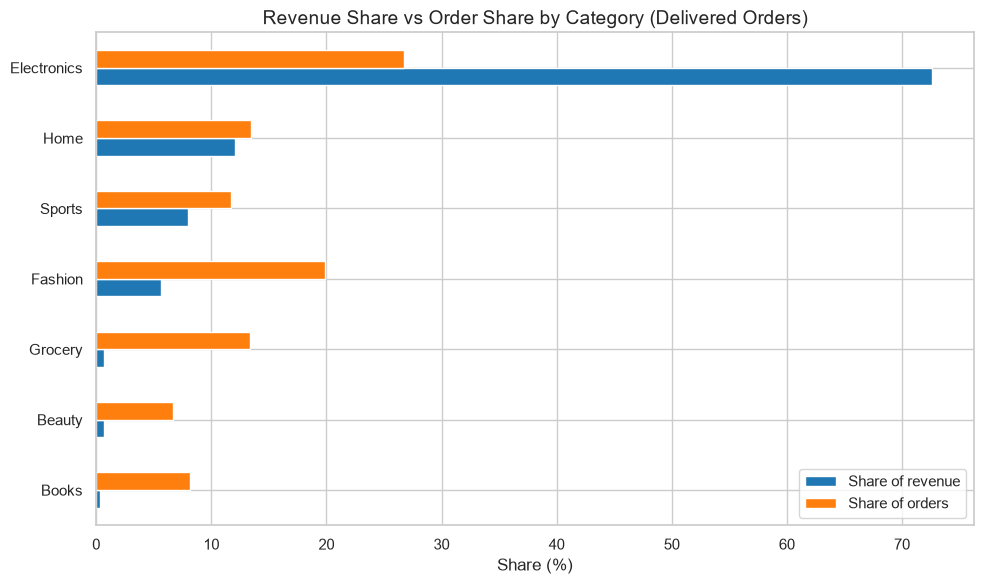

In [12]:
chart_data = cat[["Revenue_Share_%", "Order_Share_%"]].sort_values("Revenue_Share_%")

fig, ax = plt.subplots(figsize=(10, 6))
chart_data.plot(kind="barh", ax=ax, color=["#1f77b4", "#ff7f0e"])

ax.set_title("Revenue Share vs Order Share by Category (Delivered Orders)", fontsize=14)
ax.set_xlabel("Share (%)")
ax.set_ylabel("")
ax.legend(["Share of revenue", "Share of orders"])
plt.tight_layout()
plt.savefig("../images/02_category_share.png", dpi=150, bbox_inches="tight")
plt.show()

In [13]:
brand = delivered.groupby("Brand").agg(
    Revenue=("Total_Amount", "sum"),
    Orders=("Order_ID", "count"),
    Category=("Category", "first")
)
brand["Revenue_Cr"] = brand["Revenue"] / 1e7
brand["Revenue_Share_%"] = brand["Revenue"] / brand["Revenue"].sum() * 100

top_brands = brand.sort_values("Revenue", ascending=False).head(10)
top_brands[["Category", "Revenue_Cr", "Revenue_Share_%", "Orders"]]

,Category,Revenue_Cr,Revenue_Share_%,Orders
Brand,,,,
HP,Electronics,75.49,15.92,10744
Noise,Electronics,72.95,15.39,10743
boAt,Electronics,67.24,14.18,10704
Samsung,Electronics,67.03,14.14,10676
Apple,Electronics,61.61,12.99,10709
Nike,Sports,13.96,2.94,12660
Puma,Fashion,12.98,2.74,12962
Urban,Home,12.17,2.57,5332
Godrej,Home,12.02,2.53,5402


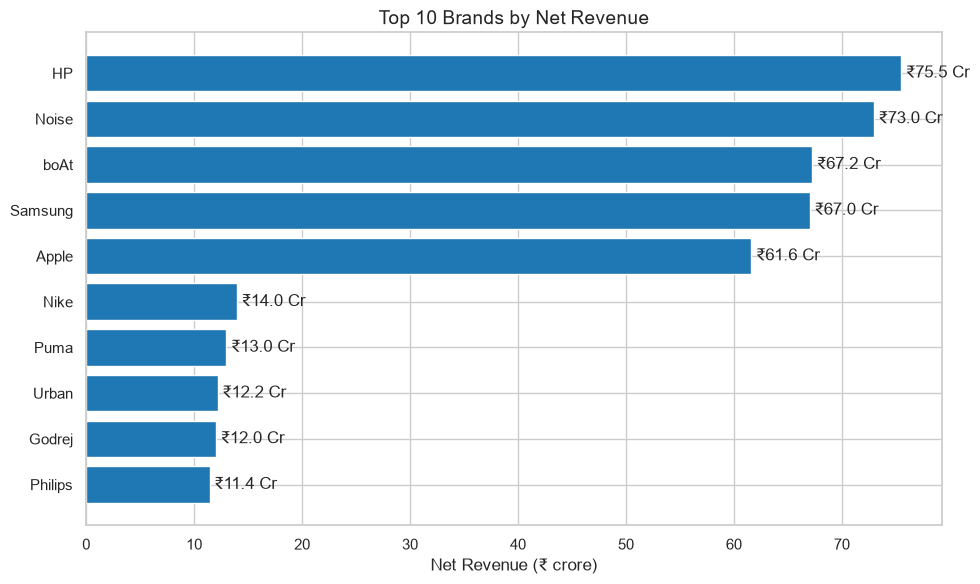

In [14]:
fig, ax = plt.subplots(figsize=(10, 6))
plot_data = top_brands.sort_values("Revenue_Cr")
ax.barh(plot_data.index, plot_data["Revenue_Cr"], color="#1f77b4")

for i, value in enumerate(plot_data["Revenue_Cr"]):
    ax.text(value, i, f" ₹{value:.1f} Cr", va="center")

ax.set_title("Top 10 Brands by Net Revenue", fontsize=14)
ax.set_xlabel("Net Revenue (₹ crore)")
plt.tight_layout()
plt.savefig("../images/03_top_brands.png", dpi=150, bbox_inches="tight")
plt.show()

**Insight (categories and brands):**
- Electronics is the largest category, with ~72% of revenue from only ~27% of orders (high-value category).
- Fashion has ~20% of orders but only ~6% of revenue (high-volume, low-value category). Grocery, Beauty and Books are even more extreme: together ~28% of orders but under 2% of revenue.
- The top 10 brands together generate ~86% of revenue; the leading brand is HP (₹75.5 crore).
- The top 5 brands (HP, Noise, boAt, Samsung, Apple) are all Electronics and together earn ₹344 crore, about 73% of Net Revenue. The business depends heavily on one category and five brands.
- Low-value categories pay shipping most often: Books (30.4%) and Grocery (26.4%) orders frequently fall below the ₹500 free-shipping threshold, versus 0% for Electronics and Sports.
- Recommendation: offer bundles or "add ₹X more for free shipping" prompts in Books, Grocery and Beauty to raise their order values above ₹500.

In [15]:
(1 - delivered.groupby("Category")["Free_Shipping"].mean()).mul(100).round(1).sort_values(ascending=False)

Category
Books         30.40
Grocery       26.40
Beauty         9.50
Fashion        1.60
Home           0.60
Electronics    0.00
Sports         0.00
Name: Free_Shipping, dtype: float64

## 4. Geography

**Question:** Which states and cities generate the most revenue? Do states differ in how much customers spend per order, or only in how many orders they place?

In [16]:
state = delivered.groupby("State").agg(
    Revenue=("Total_Amount", "sum"),
    Orders=("Order_ID", "count"),
    Customers=("Customer_ID", "nunique"),
    Median_Order=("Total_Amount", "median")
)
state["Revenue_Cr"] = state["Revenue"] / 1e7
state["Revenue_Share_%"] = state["Revenue"] / state["Revenue"].sum() * 100
state["Orders_per_Customer"] = state["Orders"] / state["Customers"]

state = state.sort_values("Revenue", ascending=False)
state[["Revenue_Cr", "Revenue_Share_%", "Orders", "Customers", "Orders_per_Customer", "Median_Order"]]

,Revenue_Cr,Revenue_Share_%,Orders,Customers,Orders_per_Customer,Median_Order
State,,,,,,
Uttar Pradesh,61.87,13.05,26134,5186,5.04,"8,407.85"
Rajasthan,60.47,12.75,25440,5032,5.06,"8,396.32"
Haryana,59.77,12.61,25656,5091,5.04,"8,143.82"
Maharashtra,48.48,10.22,20364,4028,5.06,"8,296.32"
Punjab,47.68,10.06,20240,4058,4.99,"8,107.87"
Gujarat,47.60,10.04,20141,3989,5.05,"8,203.62"
Delhi,38.17,8.05,15614,3095,5.04,"8,493.68"
Tamil Nadu,37.60,7.93,15804,3144,5.03,"8,203.62"
West Bengal,36.47,7.69,15514,3111,4.99,"8,434.23"


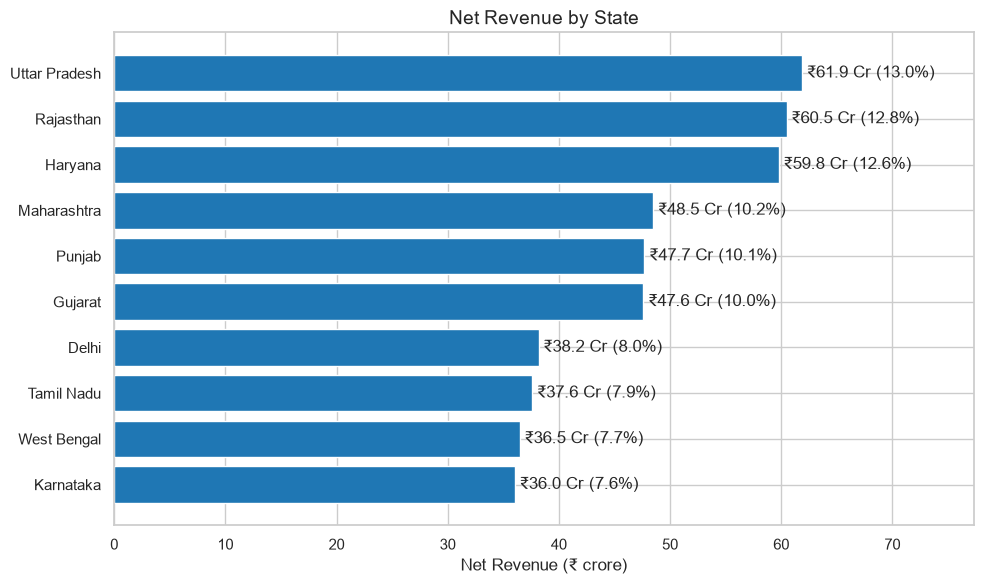

In [17]:
fig, ax = plt.subplots(figsize=(10, 6))
plot_data = state.sort_values("Revenue_Cr")
ax.barh(plot_data.index, plot_data["Revenue_Cr"], color="#1f77b4")

for i, (value, share) in enumerate(zip(plot_data["Revenue_Cr"], plot_data["Revenue_Share_%"])):
    ax.text(value, i, f" ₹{value:.1f} Cr ({share:.1f}%)", va="center")

ax.set_title("Net Revenue by State", fontsize=14)
ax.set_xlabel("Net Revenue (₹ crore)")
ax.set_xlim(0, plot_data["Revenue_Cr"].max() * 1.25)
plt.tight_layout()
plt.savefig("../images/04_revenue_by_state.png", dpi=150, bbox_inches="tight")
plt.show()

In [18]:
city = delivered.groupby(["City", "State"]).agg(
    Revenue=("Total_Amount", "sum"),
    Orders=("Order_ID", "count")
)
city["Revenue_Cr"] = city["Revenue"] / 1e7
city["Revenue_Share_%"] = city["Revenue"] / city["Revenue"].sum() * 100

city.sort_values("Revenue", ascending=False).head(10)[["Revenue_Cr", "Revenue_Share_%", "Orders"]]

,,Revenue_Cr,Revenue_Share_%,Orders
City,State,,,
Madurai,Tamil Nadu,13.60,2.87,5586
New Delhi,Delhi,13.37,2.82,5447
Howrah,West Bengal,12.71,2.68,5475
Dwarka,Delhi,12.66,2.67,5261
Kanpur,Uttar Pradesh,12.65,2.67,5309
Varanasi,Uttar Pradesh,12.61,2.66,5415
Amritsar,Punjab,12.61,2.66,5231
Vadodara,Gujarat,12.50,2.64,5309
Thane,Maharashtra,12.47,2.63,5176


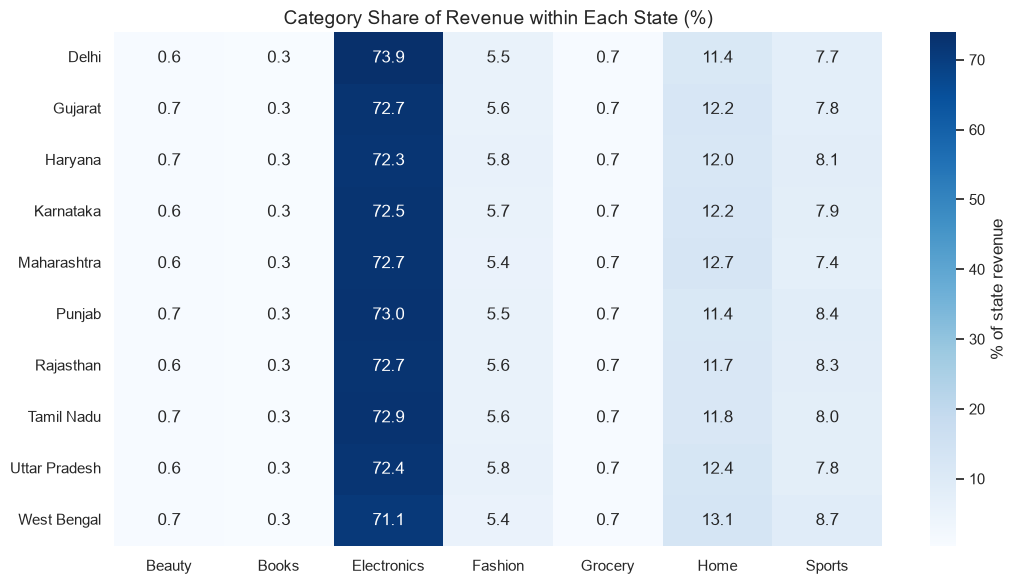

In [19]:
mix = pd.crosstab(delivered["State"], delivered["Category"],
                  values=delivered["Total_Amount"], aggfunc="sum",
                  normalize="index") * 100

fig, ax = plt.subplots(figsize=(11, 6))
sns.heatmap(mix, annot=True, fmt=".1f", cmap="Blues", ax=ax, cbar_kws={"label": "% of state revenue"})
ax.set_title("Category Share of Revenue within Each State (%)", fontsize=14)
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig("../images/05_state_category_mix.png", dpi=150, bbox_inches="tight")
plt.show()

**Insight (geography):**
- By total revenue, Uttar Pradesh leads (₹61.87 crore, 13.05%), followed by Rajasthan (₹60.47 crore) and Haryana (₹59.77 crore).
- However, this ranking reflects how many cities each state has in the data, not market strength. States with 5 cities rank above states with 4, which rank above states with 3. Revenue per city is nearly identical everywhere (₹11.90–12.72 crore).
- Adjusted per city, Delhi (₹12.72 crore) and Tamil Nadu (₹12.53 crore) are the strongest, despite ranking 7th and 8th by total.
- Customer behaviour is the same across states: ~5 delivered orders per customer, median order ₹8,100–8,450, and Electronics at 71–74% of revenue everywhere.
- The top city is Madurai (₹13.60 crore, 2.87%), but the top 10 cities are within ₹1.2 crore of each other; no city dominates.
- Recommendation: Growth should come from expanding into new cities, since each city contributes a similar amount. A single national product and pricing strategy is sufficient.

In [20]:
state["Cities"] = delivered.groupby("State")["City"].nunique()
state["Revenue_per_City_Cr"] = state["Revenue_Cr"] / state["Cities"]
state[["Revenue_Cr", "Cities", "Revenue_per_City_Cr"]]

,Revenue_Cr,Cities,Revenue_per_City_Cr
State,,,
Uttar Pradesh,61.87,5,12.37
Rajasthan,60.47,5,12.09
Haryana,59.77,5,11.95
Maharashtra,48.48,4,12.12
Punjab,47.68,4,11.92
Gujarat,47.60,4,11.90
Delhi,38.17,3,12.72
Tamil Nadu,37.60,3,12.53
West Bengal,36.47,3,12.16


## 5. Customers

**Question:** How do customer tiers, age groups and gender differ in spending? Does Customer_Tier actually reflect how much customers spend?

In [21]:
cust = delivered.groupby("Customer_ID").agg(
    Revenue=("Total_Amount", "sum"),
    Orders=("Order_ID", "count"),
    Tier=("Customer_Tier", "first"),
    Gender=("Gender", "first")
)
print(cust.shape)
cust.head()

(39726, 4)


,Revenue,Orders,Tier,Gender
Customer_ID,,,,
CUST00000001,"40,098.48",5,Gold,male
CUST00000002,"63,676.24",8,Platinum,male
CUST00000004,"288,324.84",5,Platinum,male
CUST00000005,"69,265.75",4,Platinum,female
CUST00000006,"195,157.41",6,Platinum,female


In [22]:
cust["Tier"].value_counts()

Tier
Platinum    27349
Gold         6692
Silver       5685
Name: count, dtype: int64

In [23]:
tier = cust.groupby("Tier").agg(
    Customers=("Revenue", "count"),
    Avg_Revenue=("Revenue", "mean"),
    Median_Revenue=("Revenue", "median"),
    Avg_Orders=("Orders", "mean")
)
tier["Customer_Share_%"] = tier["Customers"] / tier["Customers"].sum() * 100
tier["Revenue_Share_%"] = cust.groupby("Tier")["Revenue"].sum() / cust["Revenue"].sum() * 100

tier.sort_values("Avg_Revenue", ascending=False)

,Customers,Avg_Revenue,Median_Revenue,Avg_Orders,Customer_Share_%,Revenue_Share_%
Tier,,,,,,
Platinum,27349,"162,907.79","135,144.88",5.61,68.84,93.96
Gold,6692,"34,733.20","34,704.92",4.28,16.85,4.90
Silver,5685,"9,457.65","8,962.28",3.16,14.31,1.13


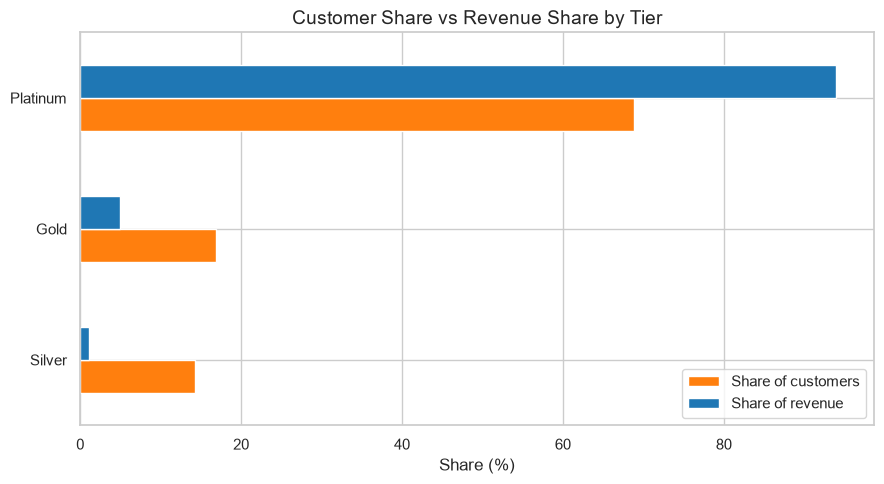

In [24]:
chart_data = tier[["Customer_Share_%", "Revenue_Share_%"]].sort_values("Revenue_Share_%")

fig, ax = plt.subplots(figsize=(9, 5))
chart_data.plot(kind="barh", ax=ax, color=["#ff7f0e", "#1f77b4"])
ax.set_title("Customer Share vs Revenue Share by Tier", fontsize=14)
ax.set_xlabel("Share (%)")
ax.set_ylabel("")
ax.legend(["Share of customers", "Share of revenue"])
plt.tight_layout()
plt.savefig("../images/06_tier_share.png", dpi=150, bbox_inches="tight")
plt.show()

In [25]:
age_order = ["18-25", "26-35", "36-45", "46-55", "56-65", "65+"]

age = delivered.groupby("Customer_Age_Group").agg(
    Revenue=("Total_Amount", "sum"),
    Orders=("Order_ID", "count"),
    Median_Order=("Total_Amount", "median")
).reindex(age_order)

age["Revenue_Share_%"] = age["Revenue"] / age["Revenue"].sum() * 100
age["Order_Share_%"] = age["Orders"] / age["Orders"].sum() * 100
age[["Revenue_Share_%", "Order_Share_%", "Median_Order"]]

,Revenue_Share_%,Order_Share_%,Median_Order
Customer_Age_Group,,,
18-25,25.09,24.62,"5,156.55"
26-35,43.29,35.14,"13,541.05"
36-45,24.55,20.05,"14,595.40"
46-55,4.25,12.17,"2,154.21"
56-65,2.15,6.07,"2,137.31"
65+,0.66,1.94,"2,036.53"


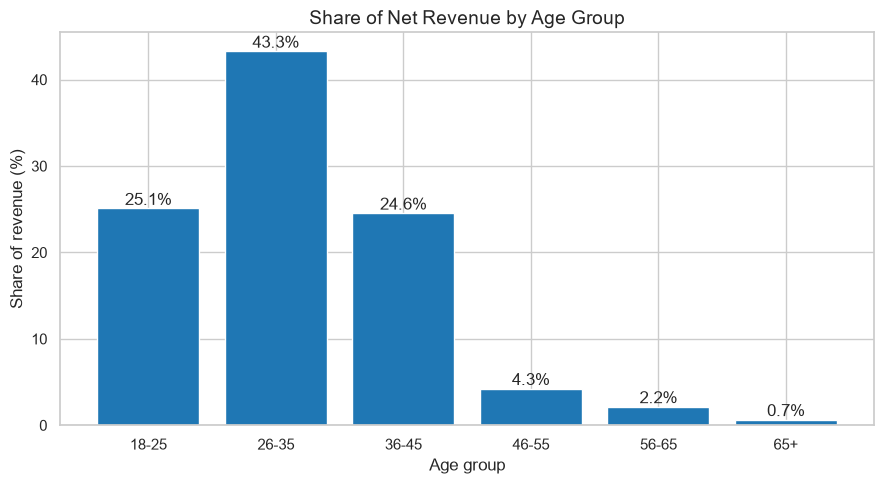

In [26]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(age.index, age["Revenue_Share_%"], color="#1f77b4")
for i, v in enumerate(age["Revenue_Share_%"]):
    ax.text(i, v, f"{v:.1f}%", ha="center", va="bottom")
ax.set_title("Share of Net Revenue by Age Group", fontsize=14)
ax.set_xlabel("Age group")
ax.set_ylabel("Share of revenue (%)")
plt.tight_layout()
plt.savefig("../images/07_age_groups.png", dpi=150, bbox_inches="tight")
plt.show()

In [27]:
gender = cust.groupby("Gender").agg(
    Customers=("Revenue", "count"),
    Avg_Revenue=("Revenue", "mean"),
    Median_Revenue=("Revenue", "median"),
    Avg_Orders=("Orders", "mean")
)
gender["Customer_Share_%"] = gender["Customers"] / gender["Customers"].sum() * 100
gender

,Customers,Avg_Revenue,Median_Revenue,Avg_Orders,Customer_Share_%
Gender,,,,,
female,19851,"119,963.92","91,316.11",5.04,49.97
male,19875,"118,750.32","90,490.94",5.04,50.03


**Insight (customers):**
- Tiers: Platinum customers are 68.8% of customers (27,349 of 39,726) but generate 94.0% of revenue. Gold (16.9% of customers) and Silver (14.3%) together generate only 6.0%. Tier reflects actual spending: average spend ranges from ₹9,458 (Silver) to ₹1,62,908 (Platinum), about 17× higher.
- The gap comes mainly from order size, not frequency: Platinum customers place 1.8× more orders than Silver (5.61 vs 3.16), but each order is ~10× larger (~₹29,000 vs ~₹3,000).
- Age: the 26–35 group contributes the most revenue (43.3%) from 35.1% of orders; customers aged 18–35 generate 68.4% of revenue, and 18–45 generate 92.9%.
- Median order value differs sharply by age: ₹13,500–14,600 for 26–45, ₹5,200 for 18–25, and only ~₹2,000–2,150 for 46+. Customers aged 46+ place 20% of orders but generate just 7% of revenue.
- Gender: no meaningful difference. Customers are split 50/50, with average spend of ₹1,19,964 (female) vs ₹1,18,750 (male), a 1% gap, and identical orders per customer (5.04).
- Recommendation: Prioritise retaining Platinum customers (94% of revenue) and target the 26–45 age group for high-value categories. Gender-based targeting is unlikely to add value.
-  Age: customers aged 26–45 have much higher median orders (₹13,500–14,600) than 18–25 (₹5,200) and 46+ (~₹2,000).
- However, the age-category heatmap shows each age group buys from exactly three categories in equal thirds, with 0% in all others (e.g. customers aged 46+ never buy Electronics). This is a rule built into the simulated data, not real behaviour, so the age-spending pattern should not be used for targeting decisions.
- Recommendation: Prioritise retaining Platinum customers (94% of revenue). Age and gender findings are not reliable bases for targeting in this dataset.

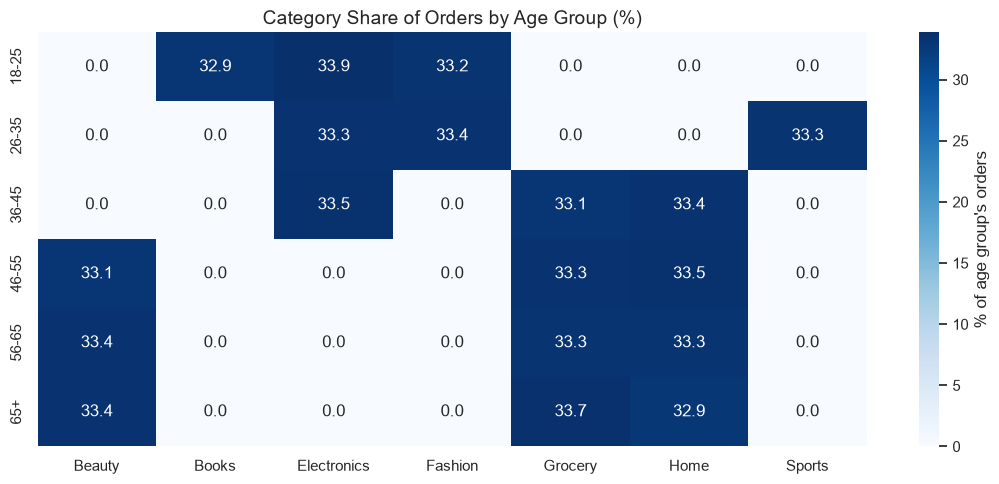

In [28]:
age_mix = pd.crosstab(delivered["Customer_Age_Group"], delivered["Category"],
                      normalize="index").reindex(age_order) * 100

fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(age_mix, annot=True, fmt=".1f", cmap="Blues", ax=ax, cbar_kws={"label": "% of age group's orders"})
ax.set_title("Category Share of Orders by Age Group (%)", fontsize=14)
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig("../images/08_age_category_mix.png", dpi=150, bbox_inches="tight")
plt.show()

## Limitations

This dataset is simulated (the Kaggle description states it was created to mimic a real e-commerce database). Several patterns confirm this and limit how far the findings can be applied to real business decisions:

1. **Order statuses:** Cancelled, Returned, Shipped and Processing are each almost exactly 5% of orders, and all statuses are spread evenly over the full two years (e.g. "Processing" orders from June 2024). Real in-progress orders would be recent only.
2. **No seasonality:** Revenue is flat month to month with no Diwali or festive uplift, which is unusual for Indian e-commerce.
3. **Ratings:** Ratings range only from 3 to 5; there are no 1- or 2-star ratings, so customer dissatisfaction cannot be studied.
4. **Delivery times:** Delivery days are evenly spread between 2 and 7 (mean exactly 4.5), suggesting random assignment.
5. **Geographic coverage:** Only 10 states and 39 cities are included. State rankings reflect how many cities each state has in the data, not market size.
6. **Age and category:** Each age group buys from exactly three categories in equal proportions (0% elsewhere), a clear simulation rule. Age-based and category-based findings are therefore linked by design.
7. **Customer tiers:** 69% of customers are Platinum and there is no entry-level tier, unlike typical loyalty pyramids.
8. **Brand rankings:** Budget brands (Noise, boAt) out-earn Apple and Samsung, which may not reflect real market positions since product prices appear simulated.
9. **Small groups:** The 65+ age group is only ~2% of orders, so conclusions about it are less reliable.
**What remains valid:** data-quality methods, metric definitions (GMV vs Net Revenue), business rules found in the data (free shipping above ~₹500, flat coupons without a minimum order value), and the analytical approach (normalising by days and by cities before comparing).
10. **Payment mode:** Cancellation and return rates are identical across payment modes (chi-square p = 0.96). In real Indian e-commerce, COD orders are typically cancelled or refused more often, so this further suggests order statuses were randomly assigned.
11. **Delivery vs ratings:** Delivery time and rating are unrelated (correlation −0.002). Because both appear randomly generated, the data cannot show whether faster delivery improves satisfaction; this would need to be tested with real data.
12. **Review text:** Only 9 unique review texts exist across 120,030 reviews, three fixed phrases per star rating. Reviews are templates, so text or sentiment analysis would add no information beyond the star rating.

## 6. Payments and Cancellations

**Question:** Which payment modes do customers use, and are Cash on Delivery (COD) orders cancelled or returned more often than prepaid orders?

**Note:** This section uses all orders (not just delivered), because cancellations and returns are only visible in the full data.

In [29]:
df["Is_Cancelled"] = df["Order_Status"] == "Cancelled"
df["Is_Returned"] = df["Order_Status"] == "Returned"
df["Is_Lost"] = df["Status_Group"] == "Lost"

In [30]:
pay = df.groupby("Payment_Mode").agg(
    Orders=("Order_ID", "count"),
    Median_Order=("Total_Amount", "median"),
    Cancel_Rate=("Is_Cancelled", "mean"),
    Return_Rate=("Is_Returned", "mean"),
    Lost_Rate=("Is_Lost", "mean")
)
pay["Order_Share_%"] = pay["Orders"] / pay["Orders"].sum() * 100
pay[["Cancel_Rate", "Return_Rate", "Lost_Rate"]] = pay[["Cancel_Rate", "Return_Rate", "Lost_Rate"]] * 100

pay = pay.sort_values("Orders", ascending=False)
pay[["Orders", "Order_Share_%", "Median_Order", "Cancel_Rate", "Return_Rate", "Lost_Rate"]]

,Orders,Order_Share_%,Median_Order,Cancel_Rate,Return_Rate,Lost_Rate
Payment_Mode,,,,,,
UPI,128474,51.39,"8,881.26",5.06,4.92,9.98
COD,82093,32.84,"7,452.30",4.90,5.10,10.00
Debit Card,28856,11.54,"7,948.63",5.04,5.01,10.05
Credit Card,10577,4.23,"8,803.05",5.01,5.11,10.12


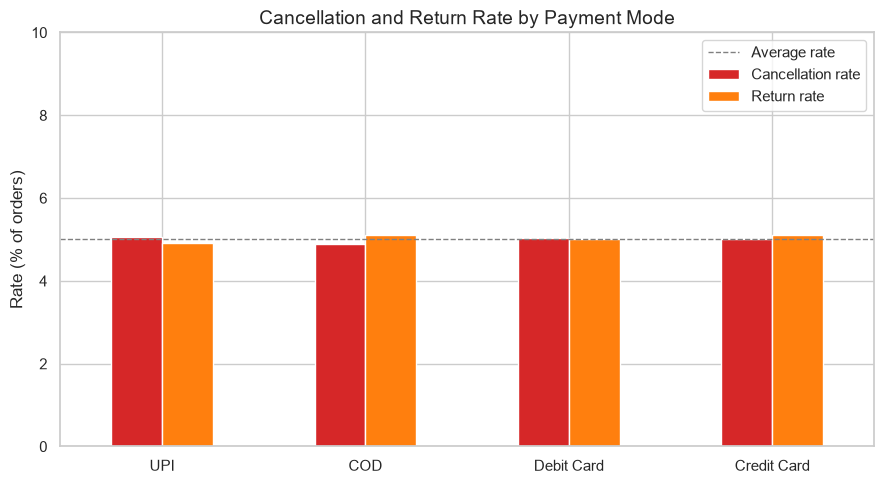

In [31]:
overall_lost = df["Is_Lost"].mean() * 100

fig, ax = plt.subplots(figsize=(9, 5))
pay[["Cancel_Rate", "Return_Rate"]].plot(kind="bar", ax=ax, color=["#d62728", "#ff7f0e"])
ax.axhline(overall_lost / 2, color="gray", linestyle="--", linewidth=1, label="Average rate (~5%)")

ax.set_title("Cancellation and Return Rate by Payment Mode", fontsize=14)
ax.set_xlabel("")
ax.set_ylabel("Rate (% of orders)")
ax.set_ylim(0, 10)
plt.xticks(rotation=0)
ax.legend(["Average rate", "Cancellation rate", "Return rate"])
plt.tight_layout()
plt.savefig("../images/09_payment_risk.png", dpi=150, bbox_inches="tight")
plt.show()

In [32]:
from scipy.stats import chi2_contingency

table = pd.crosstab(df["Payment_Mode"], df["Is_Lost"])
chi2, p_value, dof, expected = chi2_contingency(table)

print(table, "\n")
print(f"p-value: {p_value:.4f}")
if p_value < 0.05:
    print("The lost rate differs significantly between payment modes.")
else:
    print("No significant difference: payment modes have the same lost rate (differences are random).")

Is_Lost        False  True 
Payment_Mode               
COD            73886   8207
Credit Card     9507   1070
Debit Card     25956   2900
UPI           115651  12823 

p-value: 0.9617
No significant difference: payment modes have the same lost rate (differences are random).


**Insight (payments and cancellations):**
- UPI is the most used payment mode (51.4% of orders), followed by COD (32.8%), Debit Card (11.5%) and Credit Card (4.2%).
- Cancellation and return rates are ~5% for every payment mode, and the combined lost rate is 9.98–10.12% across all four. A chi-square test (p = 0.96) finds no evidence of a difference: COD orders are not riskier than prepaid orders in this data.
- Median order value differs modestly by payment mode: UPI (₹8,881) and Credit Card (₹8,803) orders are slightly larger than Debit Card (₹7,949) and COD (₹7,452), so COD customers tend to place somewhat smaller orders.
- This contradicts typical Indian e-commerce experience, where COD has higher cancellation and refusal rates, and is consistent with order statuses being randomly assigned (see Limitations).

## 7. Coupons

**Question:** How much do coupons cost the business, do coupon orders have larger baskets, and are coupons used at the right time (e.g. DIWALI100 during Diwali)?

In [33]:
coupon = delivered.groupby("Coupon_Code").agg(
    Orders=("Order_ID", "count"),
    Median_Order_Value=("Order_Value", "median"),
    Avg_Discount=("Coupon_Discount", "mean"),
    Total_Discount=("Coupon_Discount", "sum")
)
coupon["Order_Share_%"] = coupon["Orders"] / coupon["Orders"].sum() * 100
coupon["Discount_Cr"] = coupon["Total_Discount"] / 1e7

coupon.sort_values("Orders", ascending=False)

,Orders,Median_Order_Value,Avg_Discount,Total_Discount,Order_Share_%,Discount_Cr
Coupon_Code,,,,,,
No Coupon,159983,"8,342.02",0.00,0.00,79.94,0.00
SAVE10,19971,"8,508.72","2,430.72","48,543,922.55",9.98,4.85
FLAT50,10120,"8,948.13",50.00,"506,000.00",5.06,0.05
DIWALI100,10065,"8,727.88",100.00,"1,006,500.00",5.03,0.10


In [34]:
with_coupon = delivered[delivered["Has_Coupon"]].copy()
with_coupon["Discount_%"] = with_coupon["Coupon_Discount"] / with_coupon["Order_Value"] * 100

print("Discount amount (₹) per coupon:")
print(with_coupon.groupby("Coupon_Code")["Coupon_Discount"].agg(["min", "median", "max"]), "\n")

print("Discount as % of order value:")
print(with_coupon.groupby("Coupon_Code")["Discount_%"].agg(["min", "median", "max"]))

Discount amount (₹) per coupon:
               min  median       max
Coupon_Code                         
DIWALI100   100.00  100.00    100.00
FLAT50       50.00   50.00     50.00
SAVE10        2.61  850.87 38,279.16 

Discount as % of order value:
             min  median    max
Coupon_Code                    
DIWALI100   0.02    1.15 382.70
FLAT50      0.01    0.56 191.35
SAVE10      9.99   10.00  10.01


In [35]:
total_discount = delivered["Coupon_Discount"].sum()
print(f"Total coupon discount given: ₹{total_discount/1e7:.2f} crore")
print(f"As % of Net Revenue: {total_discount / net_revenue * 100:.2f}%")
print()
print((coupon["Total_Discount"] / total_discount * 100).round(1).sort_values(ascending=False).rename("Share of discount cost %"))

Total coupon discount given: ₹5.01 crore
As % of Net Revenue: 1.06%

Coupon_Code
SAVE10      97.00
DIWALI100    2.00
FLAT50       1.00
No Coupon    0.00
Name: Share of discount cost %, dtype: float64


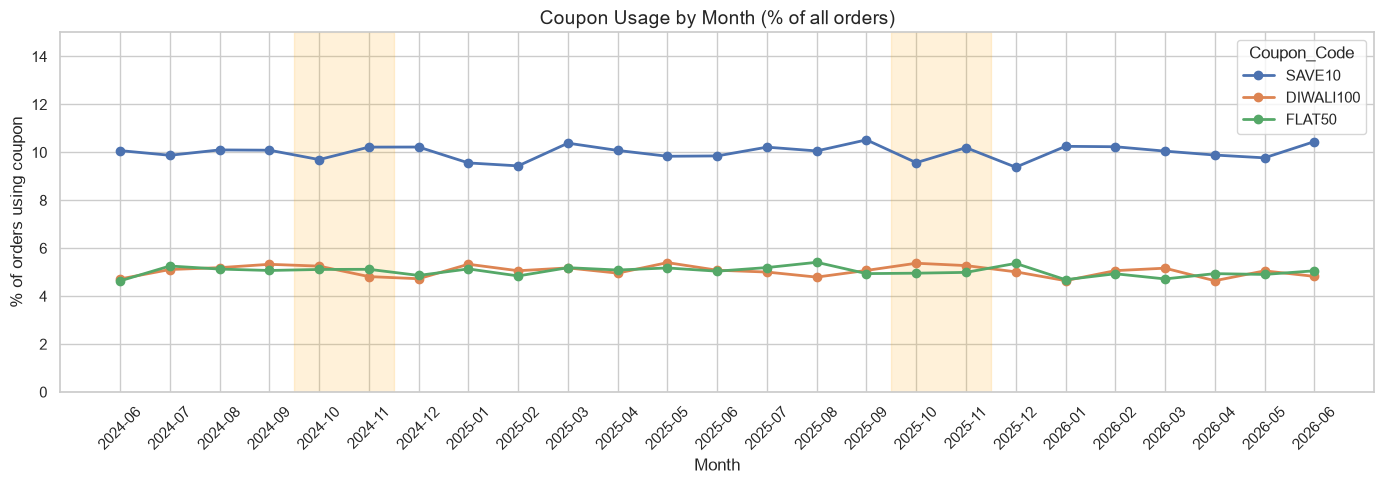

In [36]:
coupon_monthly = pd.crosstab(df["Year_Month"], df["Coupon_Code"], normalize="index") * 100
coupon_lines = coupon_monthly[["SAVE10", "DIWALI100", "FLAT50"]]

fig, ax = plt.subplots(figsize=(14, 5))
coupon_lines.plot(ax=ax, marker="o", linewidth=2)

months = list(coupon_monthly.index)
for start in ["2024-10", "2025-10"]:
    i = months.index(start)
    ax.axvspan(i - 0.5, i + 1.5, color="orange", alpha=0.15)

ax.set_title("Coupon Usage by Month (% of all orders)", fontsize=14)
ax.set_xlabel("Month")
ax.set_ylabel("% of orders using coupon")
ax.set_ylim(0, 15)
ax.set_xticks(range(len(months)))
ax.set_xticklabels(months, rotation=45)
plt.tight_layout()
plt.savefig("../images/10_coupon_timing.png", dpi=150, bbox_inches="tight")
plt.show()

In [37]:
festive = coupon_monthly.index.isin(["2024-10", "2024-11", "2025-10", "2025-11"])
print(f"DIWALI100 share in festive months: {coupon_monthly.loc[festive, 'DIWALI100'].mean():.2f}%")
print(f"DIWALI100 share in other months:   {coupon_monthly.loc[~festive, 'DIWALI100'].mean():.2f}%")

DIWALI100 share in festive months: 5.18%
DIWALI100 share in other months:   5.02%


**Insight (coupons):**
- 20.1% of delivered orders used a coupon: SAVE10 (10.0%), DIWALI100 (5.0%), FLAT50 (5.1%).
- Coupons cost ₹5.01 crore in total (1.06% of Net Revenue); SAVE10 alone accounts for 97.0% of this cost (₹4.85 crore). The two flat coupons together cost only ₹15.1 lakh.
- SAVE10 has no maximum discount: it averages ₹2,431 per order and the largest single discount on a delivered order was ₹38,279. Flat coupons (DIWALI100, FLAT50) have no minimum order value, so discounts reach up to 383% (DIWALI100) and 191% (FLAT50) of some baskets.
- DIWALI100 is used evenly all year: 5.18% of orders in festive months vs 5.02% in other months. It behaves as a year-round discount, not a festive promotion.
- Median basket size with coupons is slightly higher than without (₹8,509–8,948 vs ₹8,342, about 2–7%). This shows association, not that coupons cause larger baskets.

In [38]:
save10 = with_coupon.loc[with_coupon["Coupon_Code"] == "SAVE10", "Coupon_Discount"]

for cap in [500, 1000, 2000]:
    savings = (save10 - cap).clip(lower=0).sum()
    affected = (save10 > cap).mean() * 100
    print(f"Cap at ₹{cap:,}: saves ₹{savings/1e7:.2f} crore ({savings/save10.sum()*100:.0f}% of SAVE10 cost); affects {affected:.0f}% of SAVE10 orders")

Cap at ₹500: saves ₹4.12 crore (85% of SAVE10 cost); affects 59% of SAVE10 orders
Cap at ₹1,000: saves ₹3.60 crore (74% of SAVE10 cost); affects 47% of SAVE10 orders
Cap at ₹2,000: saves ₹2.82 crore (58% of SAVE10 cost); affects 33% of SAVE10 orders


- Recommendations:
  1. Cap SAVE10. A cap creates a trade-off between savings and customer impact:
   - ₹500 cap: saves ₹4.12 crore (85% of SAVE10 cost), affects 59% of SAVE10 orders
   - ₹1,000 cap: saves ₹3.60 crore (74%), affects 47%
   - ₹2,000 cap: saves ₹2.82 crore (58%), affects only 33%
   Even a ₹2,000 cap removes over half the cost while leaving two-thirds of coupon users unaffected, because a few large Electronics orders drive most of the discount. These are upper-bound estimates, since some customers may not purchase without the full discount.
  2. Add a minimum order value to flat coupons (e.g. ₹499) to stop loss-making orders on low-value items.
  3. Restrict DIWALI100 to the festive season; it currently runs all year.

## 8. Delivery and Ratings

**Question:** How long do deliveries take, how satisfied are customers, and do slower deliveries lead to lower ratings?

**Note:** Ratings exist only for delivered orders, and ~60% of delivered orders were rated. Rating analysis uses only rated orders.

In [39]:
rated = delivered[delivered["Rating"].notnull()]
print("Rated orders:", len(rated))
print("Share of delivered orders rated:", round(len(rated) / len(delivered) * 100, 1), "%")

Rated orders: 120030
Share of delivered orders rated: 60.0 %


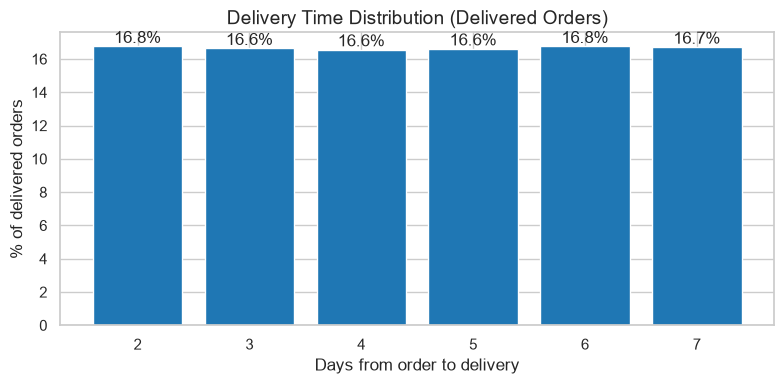

In [40]:
delivery_dist = delivered["Delivery_Days"].value_counts(normalize=True).sort_index() * 100

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(delivery_dist.index.astype(int), delivery_dist.values, color="#1f77b4")
for x, v in zip(delivery_dist.index.astype(int), delivery_dist.values):
    ax.text(x, v, f"{v:.1f}%", ha="center", va="bottom")
ax.set_title("Delivery Time Distribution (Delivered Orders)", fontsize=14)
ax.set_xlabel("Days from order to delivery")
ax.set_ylabel("% of delivered orders")
plt.tight_layout()
plt.savefig("../images/11_delivery_days.png", dpi=150, bbox_inches="tight")
plt.show()

In [41]:
rating_dist = rated["Rating"].value_counts(normalize=True).sort_index() * 100
print(rating_dist.round(1))
print(f"\nAverage rating: {rated['Rating'].mean():.2f}")

Rating
3.00   10.00
4.00   40.00
5.00   50.00
Name: proportion, dtype: float64

Average rating: 4.40


In [42]:
by_days = rated.groupby("Delivery_Days")["Rating"].agg(["mean", "count"])
by_days.index = by_days.index.astype(int)
print(by_days.round(3), "\n")

correlation = rated["Delivery_Days"].corr(rated["Rating"])
print(f"Correlation between delivery days and rating: {correlation:.3f}")

               mean  count
Delivery_Days             
2              4.40  20145
3              4.41  19991
4              4.40  19797
5              4.39  20004
6              4.40  20104
7              4.40  19989 

Correlation between delivery days and rating: -0.002


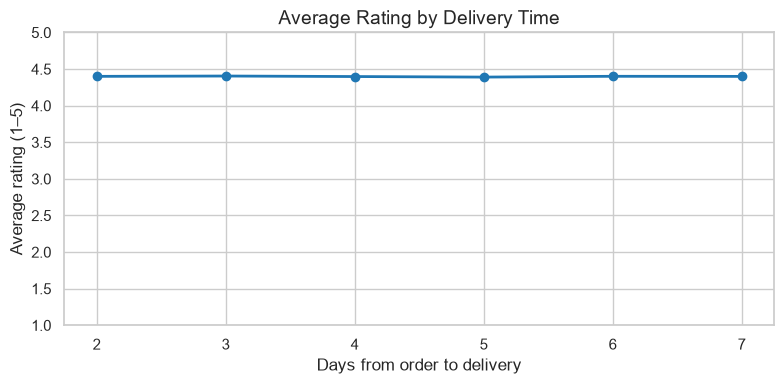

In [43]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(by_days.index, by_days["mean"], marker="o", linewidth=2, color="#1f77b4")
ax.set_ylim(1, 5)
ax.set_title("Average Rating by Delivery Time", fontsize=14)
ax.set_xlabel("Days from order to delivery")
ax.set_ylabel("Average rating (1–5)")
plt.tight_layout()
plt.savefig("../images/12_rating_vs_delivery.png", dpi=150, bbox_inches="tight")
plt.show()

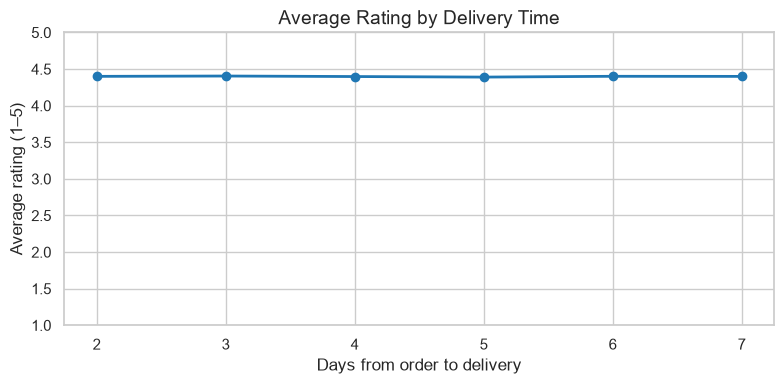

In [44]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(by_days.index, by_days["mean"], marker="o", linewidth=2, color="#1f77b4")
ax.set_ylim(1, 5)
ax.set_title("Average Rating by Delivery Time", fontsize=14)
ax.set_xlabel("Days from order to delivery")
ax.set_ylabel("Average rating (1–5)")
plt.tight_layout()
plt.savefig("../images/12_rating_vs_delivery.png", dpi=150, bbox_inches="tight")
plt.show()

In [45]:
rated.groupby("Category")["Rating"].agg(["mean", "count"]).sort_values("mean").round(3)

,mean,count
Category,,
Sports,4.39,14054
Books,4.39,9694
Grocery,4.40,16209
Electronics,4.40,32040
Beauty,4.40,8076
Home,4.40,16144
Fashion,4.41,23813


In [46]:
print("Unique review texts:", rated["Review_Text"].nunique())
rated["Review_Text"].value_counts().head(10)

Unique review texts: 9


Review_Text
Amazing quality!       20176
Highly recommended!    19992
Excellent product!     19829
Value for money        16082
Nice quality           16009
Good product           15885
Could be better         4095
Okay                    4034
Average product         3928
Name: count, dtype: int64

**Insight (delivery and ratings):**
- Deliveries take 2–7 days (median 5 days); orders are evenly spread across all six delivery times (~16.7% each).
- 60.0% of delivered orders were rated; the average rating is 4.40 (50% 5-star, 40% 4-star, 10% 3-star).
- Average rating does not change with delivery time (4.40 for 2 days vs 4.40 for 7 days); correlation = −0.002, meaning no relationship between delivery speed and customer rating.
- Ratings by category are almost identical, ranging only from 4.39 (Sports, Books) to 4.41 (Fashion).
- Reviews: only 9 unique review texts across 120,030 rated orders, so text analysis (e.g. sentiment analysis) would not be meaningful. The reviews are templates, not real customer writing.

## 9. Advanced Analysis: Pareto (80/20) and RFM Segmentation

**Questions:**
- Does a small share of products and customers generate most of the revenue (the 80/20 rule)?
- Which customer groups should the business reward, retain, or win back?

In [47]:
def pareto(revenue_by_item):
    sorted_rev = revenue_by_item.sort_values(ascending=False)
    cum_share = sorted_rev.cumsum() / sorted_rev.sum() * 100
    items_for_80 = (cum_share < 80).sum() + 1
    pct_items_for_80 = items_for_80 / len(sorted_rev) * 100
    return cum_share, items_for_80, pct_items_for_80

In [48]:
product_rev = delivered.groupby("Product_ID")["Total_Amount"].sum()
customer_rev = delivered.groupby("Customer_ID")["Total_Amount"].sum()

prod_cum, prod_n, prod_pct = pareto(product_rev)
cust_cum, cust_n, cust_pct = pareto(customer_rev)

print(f"Products sold: {len(product_rev):,} of {products.shape[0] if 'products' in dir() else 2000:,} in the catalogue")
print(f"Products: {prod_n:,} products ({prod_pct:.1f}%) generate 80% of revenue")
print(f"Customers: {cust_n:,} customers ({cust_pct:.1f}%) generate 80% of revenue")

Products sold: 2,000 of 2,000 in the catalogue
Products: 379 products (18.9%) generate 80% of revenue
Customers: 18,407 customers (46.3%) generate 80% of revenue


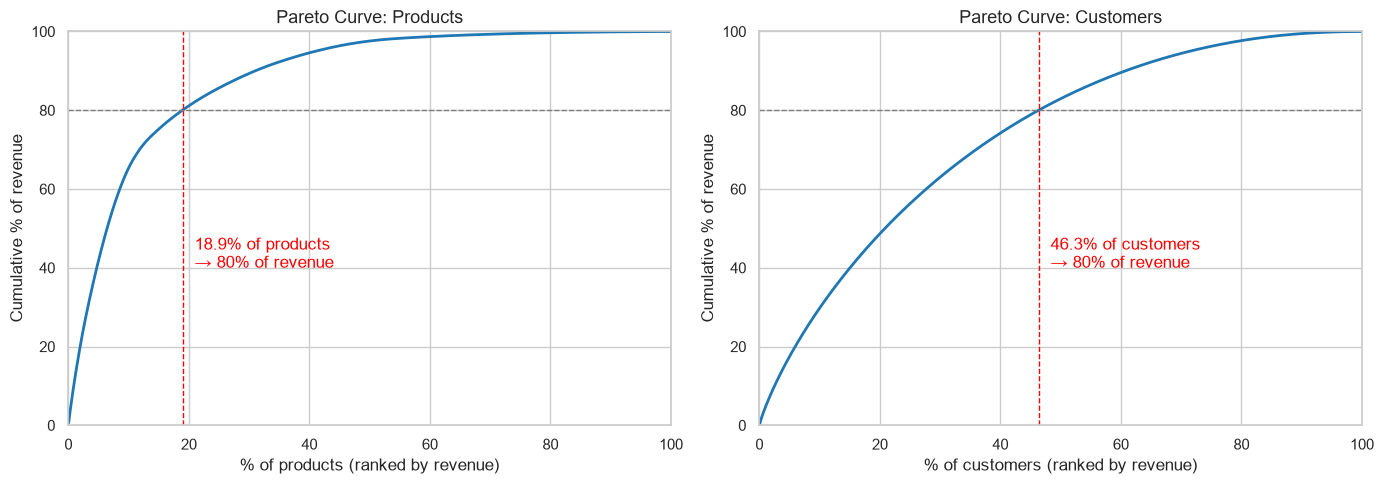

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, cum, pct, name in [(axes[0], prod_cum, prod_pct, "Products"),
                           (axes[1], cust_cum, cust_pct, "Customers")]:
    x = np.arange(1, len(cum) + 1) / len(cum) * 100
    ax.plot(x, cum.values, linewidth=2, color="#1f77b4")
    ax.axhline(80, color="gray", linestyle="--", linewidth=1)
    ax.axvline(pct, color="red", linestyle="--", linewidth=1)
    ax.text(pct + 2, 40, f"{pct:.1f}% of {name.lower()}\n→ 80% of revenue", color="red")
    ax.set_title(f"Pareto Curve: {name}", fontsize=13)
    ax.set_xlabel(f"% of {name.lower()} (ranked by revenue)")
    ax.set_ylabel("Cumulative % of revenue")
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 100)

plt.tight_layout()
plt.savefig("../images/13_pareto.png", dpi=150, bbox_inches="tight")
plt.show()

In [50]:
snapshot = delivered["Order_Date"].max() + pd.Timedelta(days=1)

rfm = delivered.groupby("Customer_ID").agg(
    Last_Order=("Order_Date", "max"),
    Frequency=("Order_ID", "count"),
    Monetary=("Total_Amount", "sum")
)
rfm["Recency"] = (snapshot - rfm["Last_Order"]).dt.days

print("Snapshot date:", snapshot.date())
rfm[["Recency", "Frequency", "Monetary"]].describe().round(1)

Snapshot date: 2026-07-01


,Recency,Frequency,Monetary
count,"39,726.00","39,726.00","39,726.00"
mean,147.70,5.00,"119,356.80"
std,138.30,2.20,"106,112.20"
min,1.00,1.00,93.80
25%,44.00,3.00,"38,646.80"
50%,106.00,5.00,"90,947.00"
75%,209.00,6.00,"170,704.30"
max,760.00,17.00,"890,131.60"


In [51]:
rfm["R_Score"] = pd.qcut(rfm["Recency"], 5, labels=[5, 4, 3, 2, 1]).astype(int)
rfm["F_Score"] = pd.qcut(rfm["Frequency"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm["M_Score"] = pd.qcut(rfm["Monetary"], 5, labels=[1, 2, 3, 4, 5]).astype(int)

rfm[["Recency", "R_Score", "Frequency", "F_Score", "Monetary", "M_Score"]].head()

,Recency,R_Score,Frequency,F_Score,Monetary,M_Score
Customer_ID,,,,,,
CUST00000001,170,2,5,3,"40,098.48",2
CUST00000002,138,3,8,5,"63,676.24",2
CUST00000004,276,1,5,3,"288,324.84",5
CUST00000005,200,2,4,2,"69,265.75",3
CUST00000006,136,3,6,4,"195,157.41",5


In [52]:
conditions = [
    (rfm["R_Score"] >= 4) & (rfm["F_Score"] >= 4),
    (rfm["R_Score"] >= 3) & (rfm["F_Score"] >= 3),
    (rfm["R_Score"] >= 4) & (rfm["F_Score"] <= 2),
    (rfm["R_Score"] <= 2) & (rfm["F_Score"] >= 3),
    (rfm["R_Score"] <= 2) & (rfm["F_Score"] <= 2),
]
segments = ["Champions", "Loyal", "New / Promising", "At Risk", "Lost"]

rfm["Segment"] = np.select(conditions, segments, default="Needs Attention")
rfm["Segment"].value_counts()

Segment
Lost               8889
Champions          8512
Loyal              8348
At Risk            6975
New / Promising    4268
Needs Attention    2734
Name: count, dtype: int64

In [53]:
seg = rfm.groupby("Segment").agg(
    Customers=("Monetary", "count"),
    Avg_Recency_Days=("Recency", "mean"),
    Avg_Orders=("Frequency", "mean"),
    Avg_Spend=("Monetary", "mean"),
    Total_Spend=("Monetary", "sum")
)
seg["Customer_Share_%"] = seg["Customers"] / seg["Customers"].sum() * 100
seg["Revenue_Share_%"] = seg["Total_Spend"] / seg["Total_Spend"].sum() * 100

seg = seg.sort_values("Revenue_Share_%", ascending=False)
seg[["Customers", "Customer_Share_%", "Revenue_Share_%", "Avg_Recency_Days", "Avg_Orders", "Avg_Spend"]].round(1)

,Customers,Customer_Share_%,Revenue_Share_%,Avg_Recency_Days,Avg_Orders,Avg_Spend
Segment,,,,,,
Champions,8512,21.40,31.20,35.10,7.40,"173,686.90"
Loyal,8348,21.00,24.30,79.50,5.80,"138,006.20"
At Risk,6975,17.60,20.80,231.80,5.90,"141,691.40"
Lost,8889,22.40,12.40,318.30,2.80,"66,295.50"
New / Promising,4268,10.70,6.80,37.70,3.30,"75,740.30"
Needs Attention,2734,6.90,4.40,108.40,3.20,"76,887.50"


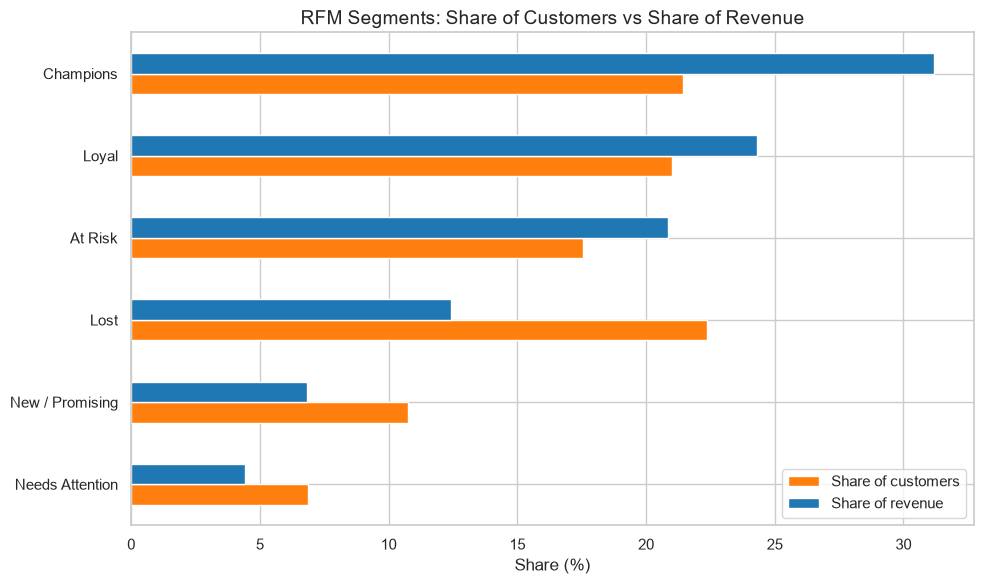

In [54]:
chart_data = seg[["Customer_Share_%", "Revenue_Share_%"]].sort_values("Revenue_Share_%")

fig, ax = plt.subplots(figsize=(10, 6))
chart_data.plot(kind="barh", ax=ax, color=["#ff7f0e", "#1f77b4"])
ax.set_title("RFM Segments: Share of Customers vs Share of Revenue", fontsize=14)
ax.set_xlabel("Share (%)")
ax.set_ylabel("")
ax.legend(["Share of customers", "Share of revenue"])
plt.tight_layout()
plt.savefig("../images/14_rfm_segments.png", dpi=150, bbox_inches="tight")
plt.show()

In [55]:
print("Products needed for 80% of revenue:", prod_n)
print("Products sold at least once:", len(product_rev))

Products needed for 80% of revenue: 379
Products sold at least once: 2000


**Insight (Pareto and RFM):**
- Products: 18.9% of products (379 of 2,000) generate 80% of revenue, close to the classic 80/20 rule. A small set of "hero" products, most likely high-priced Electronics, drives most sales. Every product in the catalogue sold at least once.
- Customers: 46.3% of customers generate 80% of revenue, so revenue is moderately spread across customers rather than dominated by a small elite.
- RFM: Champions are 21.4% of customers but generate 31.2% of revenue (7.4 orders on average, last purchase ~35 days ago). Together, Champions and Loyal customers (42.4% of customers) generate 55.5% of revenue.
- At Risk customers (17.6%, 6,975 customers) previously ordered 5.9 times on average and spent ₹1,41,691 each, more than Loyal customers (₹1,38,006), but haven't bought in ~232 days. They represent 20.8% of historic revenue (~₹99 crore) and are the priority for win-back campaigns.
- Lost customers (22.4%) ordered only 2.8 times and haven't bought in ~318 days; they generate 12.4% of revenue and are a lower priority.
- Recommendations: reward Champions (loyalty perks, early access); protect stock availability of the 379 hero products; target At Risk customers with personalised win-back offers; convert New/Promising customers (10.7%, last purchase ~38 days ago) into repeat buyers with a second-order incentive.

In [56]:
with open("../.gitignore", "w") as f:
    f.write("data/raw/\ndata/processed/\n.ipynb_checkpoints/\n")

with open("../requirements.txt", "w") as f:
    f.write("pandas\nnumpy\nmatplotlib\nseaborn\nscipy\njupyter\n")

print("Created .gitignore and requirements.txt")

Created .gitignore and requirements.txt
